# EXPERIMENT NO: 6
# IMPLEMENTATION OF LONG SHORT-TERM MEMORY (LSTM)
# FOR SENTIMENT ANALYSIS
# ============================================================
# Name      : Ajaikumar M
# Roll No   : 24BAD005
# Course    : Deep Learning


**PART A — Dataset Preparation**

Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


Load the IMDB dataset

In [2]:
# Load IMDB dataset

vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


Examine sample reviews and labels

In [3]:
print("First review sequence:")
print(x_train[0])

print("\nFirst review label:")
print(y_train[0])

print("\nFirst 10 labels:")
print(y_train[:10])

First review sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First review label:
1

First 10 labe

In [4]:
print("Sentiment Classes:")
print("0 = Negative")
print("1 = Positive")

Sentiment Classes:
0 = Negative
1 = Positive


Check review lengths

In [5]:
review_lengths = [len(review) for review in x_train]

print("Minimum review length:", min(review_lengths))
print("Maximum review length:", max(review_lengths))
print("Average review length:", np.mean(review_lengths))

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364


Apply sequence padding

In [6]:
max_length = 200

x_train_padded = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

x_test_padded = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training data shape:", x_train_padded.shape)
print("Testing data shape:", x_test_padded.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


Create validation data

In [7]:
validation_size = 5000

x_val = x_train_padded[:validation_size]
y_val = y_train[:validation_size]

x_train_final = x_train_padded[validation_size:]
y_train_final = y_train[validation_size:]

print("Training data:", x_train_final.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test_padded.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


Part A final output

In [8]:
print("===== PART A: DATASET PREPARATION =====")
print("Vocabulary size:", vocab_size)
print("Maximum sequence length:", max_length)
print("Training samples:", len(x_train_final))
print("Validation samples:", len(x_val))
print("Testing samples:", len(x_test_padded))
print("Training input shape:", x_train_final.shape)
print("Validation input shape:", x_val.shape)
print("Testing input shape:", x_test_padded.shape)
print("Sentiment labels: 0 = Negative, 1 = Positive")

===== PART A: DATASET PREPARATION =====
Vocabulary size: 10000
Maximum sequence length: 200
Training samples: 20000
Validation samples: 5000
Testing samples: 25000
Training input shape: (20000, 200)
Validation input shape: (5000, 200)
Testing input shape: (25000, 200)
Sentiment labels: 0 = Negative, 1 = Positive


**PART B — Implementing the LSTM Model**

Build the LSTM model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dense(1, activation='sigmoid')
])

print("LSTM model created successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM model created successfully!


Compile the model

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


Display Model Summary

In [11]:
print("===== PART B: LSTM MODEL SUMMARY =====")

model.summary()

===== PART B: LSTM MODEL SUMMARY =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Clean architecture output

In [12]:
print("\n===== MODEL ARCHITECTURE =====")
print("1. Embedding Layer : 128-dimensional vectors")
print("2. LSTM Layer      : 64 units")
print("3. Dense Layer     : 1 neuron")
print("4. Activation      : Sigmoid")
print("5. Optimizer       : Adam")
print("6. Loss Function   : Binary Crossentropy")


===== MODEL ARCHITECTURE =====
1. Embedding Layer : 128-dimensional vectors
2. LSTM Layer      : 64 units
3. Dense Layer     : 1 neuron
4. Activation      : Sigmoid
5. Optimizer       : Adam
6. Loss Function   : Binary Crossentropy


**Part C: Model Training and Performance Evaluation**

Train the LSTM

In [13]:
history = model.fit(
    x_train_final,
    y_train_final,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5459 - loss: 0.6786 - val_accuracy: 0.6028 - val_loss: 0.6466
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6553 - loss: 0.6169 - val_accuracy: 0.5076 - val_loss: 0.6955
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7337 - loss: 0.5116 - val_accuracy: 0.8096 - val_loss: 0.4232
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8877 - loss: 0.2829 - val_accuracy: 0.8584 - val_loss: 0.3472
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9325 - loss: 0.1913 - val_accuracy: 0.8680 - val_loss: 0.3433


Display Training Results

In [14]:
print("===== PART C: TRAINING RESULTS =====")

for i in range(len(history.history['accuracy'])):
    print(
        f"Epoch {i+1}: "
        f"Training Accuracy = {history.history['accuracy'][i]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][i]:.4f}, "
        f"Training Loss = {history.history['loss'][i]:.4f}, "
        f"Validation Loss = {history.history['val_loss'][i]:.4f}"
    )

===== PART C: TRAINING RESULTS =====
Epoch 1: Training Accuracy = 0.5459, Validation Accuracy = 0.6028, Training Loss = 0.6786, Validation Loss = 0.6466
Epoch 2: Training Accuracy = 0.6553, Validation Accuracy = 0.5076, Training Loss = 0.6169, Validation Loss = 0.6955
Epoch 3: Training Accuracy = 0.7337, Validation Accuracy = 0.8096, Training Loss = 0.5116, Validation Loss = 0.4232
Epoch 4: Training Accuracy = 0.8877, Validation Accuracy = 0.8584, Training Loss = 0.2829, Validation Loss = 0.3472
Epoch 5: Training Accuracy = 0.9325, Validation Accuracy = 0.8680, Training Loss = 0.1913, Validation Loss = 0.3433


Evaluate on Test Data

In [15]:
# TEST SET EVALUATION

test_loss, test_accuracy = model.evaluate(
    x_test_padded,
    y_test,
    verbose=0
)

print("===== TEST SET EVALUATION =====")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

===== TEST SET EVALUATION =====
Test Loss: 0.3676
Test Accuracy: 0.8511


Calculate Accuracy, Precision, Recall and F1-Score

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# GENERATE TEST PREDICTIONS

y_prob = model.predict(
    x_test_padded,
    batch_size=64,
    verbose=1
)

y_pred = (y_prob >= 0.5).astype(int).flatten()

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


Calculate Evaluation Metrics

In [18]:
# CALCULATE PERFORMANCE METRICS

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== EVALUATION METRICS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

===== EVALUATION METRICS =====
Accuracy : 0.8511
Precision: 0.8618
Recall   : 0.8363
F1-score : 0.8488


Generate Confusion Matrix

In [19]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

print("===== CONFUSION MATRIX =====")
print(cm)

===== CONFUSION MATRIX =====
[[10823  1677]
 [ 2046 10454]]


Display Confusion Matrix Graphically

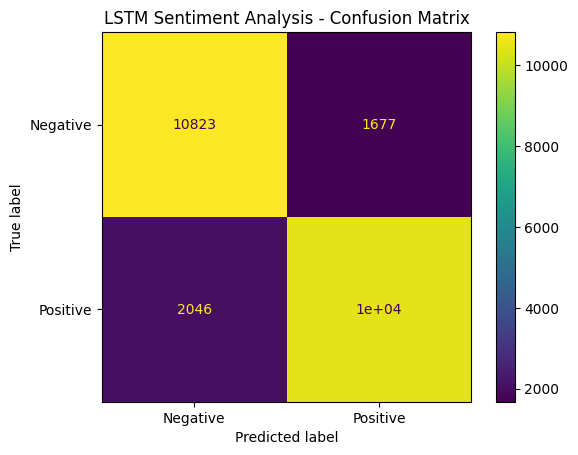

In [20]:
# DISPLAY CONFUSION MATRIX

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("LSTM Sentiment Analysis - Confusion Matrix")
plt.show()

Plot Accuracy vs Epoch

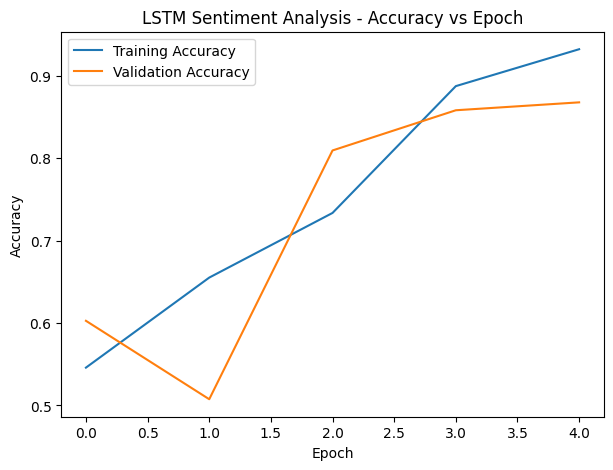

In [21]:
# ACCURACY VS EPOCH

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Sentiment Analysis - Accuracy vs Epoch')
plt.legend()
plt.show()

Plot Loss vs Epoch

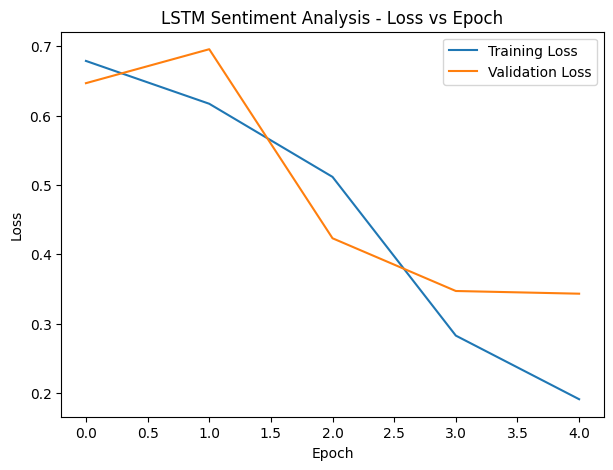

In [22]:
# LOSS VS EPOCH

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Sentiment Analysis - Loss vs Epoch')
plt.legend()
plt.show()

**Part D: Sentiment Prediction on New Reviews**

Load the IMDB Vocabulary

In [23]:
word_index = imdb.get_word_index()

print("IMDB vocabulary loaded successfully!")
print("Vocabulary size:", len(word_index))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDB vocabulary loaded successfully!
Vocabulary size: 88584


Create the Text Preprocessing Function

In [24]:
import re

def encode_review(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Split into words
    words = text.split()

    # Convert words to IMDB integer indices
    sequence = [1] + [word_index.get(word, 2) + 3 for word in words]

    # Pad the sequence
    padded_sequence = pad_sequences(
        [sequence],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    return padded_sequence

print("Review preprocessing function created successfully!")

Review preprocessing function created successfully!


Create the Sentiment Prediction Function

In [25]:
def predict_sentiment(review):
    # Convert review into model input
    sequence = encode_review(review)

    # Predict probability
    probability = model.predict(sequence, verbose=0)[0][0]

    # Classify sentiment
    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print(f"Positive Probability: {probability:.4f}")
    print("Predicted Sentiment:", sentiment)
    print("-" * 60)

Test Positive Review

In [26]:
positive_review = "This movie was excellent and I really enjoyed it."

predict_sentiment(positive_review)

Review: This movie was excellent and I really enjoyed it.
Positive Probability: 0.9669
Predicted Sentiment: Positive
------------------------------------------------------------


Test Negative Review

In [27]:
negative_review = "The movie was boring and disappointing. I hated it."

predict_sentiment(negative_review)

Review: The movie was boring and disappointing. I hated it.
Positive Probability: 0.0282
Predicted Sentiment: Negative
------------------------------------------------------------


Test Multiple Reviews

In [28]:
reviews = [
    ("This was an amazing movie with excellent acting and a wonderful story.", "Positive"),
    ("The movie was boring, slow and disappointing.", "Negative"),
    ("I loved this film because it was funny, exciting and entertaining.", "Positive"),
    ("I hated this movie because the story was terrible and poorly written.", "Negative")
]

print("===== PART D: NEW REVIEW PREDICTIONS =====")

for review, expected in reviews:
    sequence = encode_review(review)
    probability = model.predict(sequence, verbose=0)[0][0]

    predicted = "Positive" if probability >= 0.5 else "Negative"

    print("Review:", review)
    print(f"Expected Sentiment : {expected}")
    print(f"Positive Probability: {probability:.4f}")
    print(f"Predicted Sentiment : {predicted}")
    print("-" * 70)

===== PART D: NEW REVIEW PREDICTIONS =====
Review: This was an amazing movie with excellent acting and a wonderful story.
Expected Sentiment : Positive
Positive Probability: 0.9687
Predicted Sentiment : Positive
----------------------------------------------------------------------
Review: The movie was boring, slow and disappointing.
Expected Sentiment : Negative
Positive Probability: 0.0247
Predicted Sentiment : Negative
----------------------------------------------------------------------
Review: I loved this film because it was funny, exciting and entertaining.
Expected Sentiment : Positive
Positive Probability: 0.9662
Predicted Sentiment : Positive
----------------------------------------------------------------------
Review: I hated this movie because the story was terrible and poorly written.
Expected Sentiment : Negative
Positive Probability: 0.0310
Predicted Sentiment : Negative
----------------------------------------------------------------------


Calculate Correct Predictions

In [29]:
correct = 0

for review, expected in reviews:
    sequence = encode_review(review)
    probability = model.predict(sequence, verbose=0)[0][0]

    predicted = "Positive" if probability >= 0.5 else "Negative"

    if predicted == expected:
        correct += 1

print("===== PART D SUMMARY =====")
print("Total Reviews:", len(reviews))
print("Correct Predictions:", correct)
print("Incorrect Predictions:", len(reviews) - correct)
print("Prediction Accuracy:", f"{(correct / len(reviews)) * 100:.2f}%")

===== PART D SUMMARY =====
Total Reviews: 4
Correct Predictions: 4
Incorrect Predictions: 0
Prediction Accuracy: 100.00%
